# Part 2: The Sentinel

At 13:00 on Tuesday the desk's risk monitoring system fired a soft alert. By 14:00 it was clear that something in the structure of the book had broken: pair-trade sub-books that were flat all morning suddenly began bleeding P&L. The headline volatility looked normal, and no single asset moved by more than 2σ. Eyeballing returns missed it.

We have to build a **PCA-based real-time anomaly detector** that would have caught the event, and benchmark it against alternative methods.

**Structure:**
- **(a)** Q and T² statistics for every Tuesday tick
- **(b)** Detection thresholds (empirical + parametric) and latency
- **(c)** Contribution analysis: which asset broke?
- **(d)** Streaming detector with EWMA concept drift
- **(e)** Model shootout against two alternative methods
- **(f)** Observations

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from scipy.stats import norm as sp_norm, f as sp_f

# Global seed for full reproducibility per PS convention
np.random.seed(0)

DATA_DIR = '/content/The-Phantom-Lattice/Data/'

# Load Monday data (mirrors Part 1 exactly)
ticks_mon = pd.read_csv(DATA_DIR + 'ticks_mon.csv')

returns_mon = ticks_mon.pivot(
    index='timestamp',
    columns='asset_id',
    values='mid_return'
).dropna()

returns_mon.index = pd.to_datetime(returns_mon.index, format='ISO8601')

# Reproduce Part 1 PCA fit: sklearn PCA centres internally
pca_mon          = PCA()
pca_mon.fit(returns_mon.values)
eigenvalues      = pca_mon.explained_variance_
mean_mon         = pca_mon.mean_

# K = 3 chosen in Part 1(a)
K = 3
P = pca_mon.components_[:K]
tail_eigenvalues = eigenvalues[K:]

print(f" Part 1 PCA reproduced")
print(f" K = {K}")
print(f" P shape = {P.shape}")
print(f" mean_mon shape = {mean_mon.shape}")
print(f" tail λ shape = {tail_eigenvalues.shape}")
print(f" returns_mon = {returns_mon.shape}")

 Part 1 PCA reproduced
 K = 3
 P shape = (3, 12)
 mean_mon shape = (12,)
 tail λ shape = (9,)
 returns_mon = (28245, 12)


## (a) Compute the PCA-based anomaly scores

### Background: Q and T² statistics

Two complementary statistics from industrial process monitoring are used here :

**Q statistic (Squared Prediction Error / SPE):**

$$Q_t = \|r_t - P^\top P\, r_t\|^2$$

This measures **out-of-model** variation,i.e. how much of $r_t$ lies *outside* the top-$K$ factor subspace. On a normal day returns are well-explained by the top-$K$ factors and $Q_t$ is small. When a structural break occurs, the residual explodes.

**Hotelling T² statistic:**

$$T^2_t = \sum_{j=1}^{K} \frac{(r_t^\top v_j)^2}{\lambda_j}$$

This measures **in-model** variation,i.e. how far the projection of $r_t$ onto the known factor space has moved relative to Monday's calibration. $\lambda_j$ is the Monday eigenvalue acting as a scale. Under normal conditions $T^2_t \approx K$. it is inflates by anomalous factor movements.

**Key distinction:** Q and T² are complementary. Q detects disturbances *outside* the model while T² detects disturbances *inside* the model.

## Prepare Tuesday returns matrix with aligned assets and datetime index

In [72]:
ticks_tue = pd.read_csv(DATA_DIR + 'ticks_tue.csv')

returns_tue = ticks_tue.pivot(
    index='timestamp',
    columns='asset_id',
    values='mid_return'
).dropna()

# Enforce same column order as Monday
returns_tue = returns_tue[returns_mon.columns]

# Fix timestamp parsing
returns_tue.index = pd.to_datetime(returns_tue.index, format='ISO8601')

print(f"Tuesday shape : {returns_tue.shape}")
print(f"Columns match : {list(returns_tue.columns) == list(returns_mon.columns)}")
returns_tue.head(3)

Tuesday shape : (28245, 12)
Columns match : True


asset_id,S01,S02,S03,S04,S05,S06,S07,S08,S09,S10,S11,S12
timestamp,,,,,,,,,,,,
2026-06-02 09:00:00+00:00,-0.001279,-0.001785,-0.002029,-0.001559,-0.000279,0.000814,0.000751,0.000811,0.001401,0.001885,0.001280,0.000488
2026-06-02 09:00:00.840000+00:00,0.000996,0.000849,0.000772,-0.000026,-0.000030,-0.000696,-0.000992,-0.000875,-0.000453,-0.000075,0.000191,0.000712
2026-06-02 09:00:01.680000+00:00,0.000782,0.000285,-0.000605,-0.000359,-0.000405,-0.000388,-0.001498,-0.001108,-0.000284,0.001693,0.001945,0.001494


### Centring convention

Monday's PCA model stores the per-feature empirical mean as `pca_mon.mean_`, identical to `returns_mon.values.mean(axis=0)`. We use this Monday mean to centre Tuesday's returns. Any departure of Tuesday's mean from Monday's shows up as a contribution to both Q and T²,i.e. a mean shift is itself an anomaly signal.

In [74]:
X_tue = returns_tue.values
X_tue_c = X_tue - mean_mon
timestamps_tue = returns_tue.index
ts_tue_dt = pd.to_datetime(timestamps_tue, format='ISO8601')

print(f"X_tue centred shape : {X_tue_c.shape}")
print(f"First timestamp     : {ts_tue_dt[0]}")
print(f"Last timestamp      : {ts_tue_dt[-1]}")

X_tue centred shape : (28245, 12)
First timestamp     : 2026-06-02 09:00:00+00:00
Last timestamp      : 2026-06-02 15:59:59.160000+00:00


### Computing Q and T²

For each Tuesday tick $t$ with centred return vector $r_t \in \mathbb{R}^{12}$:

**Step 1: Projector** $P$ is the $(K \times 12)$ row matrix of top-$K$ Monday eigenvectors. The projection onto the factor subspace is $PP^\top$ (a $12 \times 12$ idempotent matrix).

**Step 2: Q** Residual $e_t = r_t - PP^\top r_t = (I - PP^\top)r_t$.

Then $Q_t = \|e_t\|^2$.

**Step 3: T²** PC scores $s_t = Pr_t \in \mathbb{R}^K$. Then $T^2_t = \sum_{j=1}^K s_{t,j}^2 / \lambda_j$ using Monday's eigenvalues as scale.

Both computed in a single vectorised pass over all $T_{\text{tue}}$ rows.

In [75]:
# Projection matrix (12×12)
Proj = P.T @ P

# Q statistic
residuals_tue = X_tue_c - X_tue_c @ Proj.T
Q_tue = np.sum(residuals_tue ** 2, axis=1)

# Hotelling T²
scores_tue = X_tue_c @ P.T
T2_tue = np.sum(scores_tue ** 2 / eigenvalues[:K], axis=1)

print(f"Q_tue  range: [{Q_tue.min():.4e}, {Q_tue.max():.4e}]")
print(f"T2_tue range: [{T2_tue.min():.4f}, {T2_tue.max():.4f}]")

Q_tue  range: [3.0389e-08, 6.4344e-05]
T2_tue range: [0.0015, 26.9193]


### Monday baseline scores

We compute Q and T² on Monday's ticks to get the **in-control distribution**. The 99th percentile of these series becomes our empirical detection threshold. Monday returns are centred by `mean_mon`, which is used by `pca_mon` during fitting, so these are the in-sample PCA residuals.

In [77]:
X_mon_c = returns_mon.values - mean_mon
residuals_mon = X_mon_c - X_mon_c @ Proj.T
Q_mon = np.sum(residuals_mon ** 2, axis=1)
scores_mon = X_mon_c @ P.T
T2_mon = np.sum(scores_mon ** 2 / eigenvalues[:K], axis=1)

print(f"Q_mon range: [{Q_mon.min():.4e}, {Q_mon.max():.4e}]")
print(f"T2_mon range: [{T2_mon.min():.4f}, {T2_mon.max():.4f}]")

Q_mon range: [2.9845e-08, 3.0947e-06]
T2_mon range: [0.0025, 32.1182]


### Plot: Q and T² for Tuesday

Event window **13:00–14:00 UTC** shaded in red. We expect both statistics to be stable during the morning session and spike sharply during the event window. The two subplots share a time axis so relative timing of Q vs T² spikes can be compared directly.

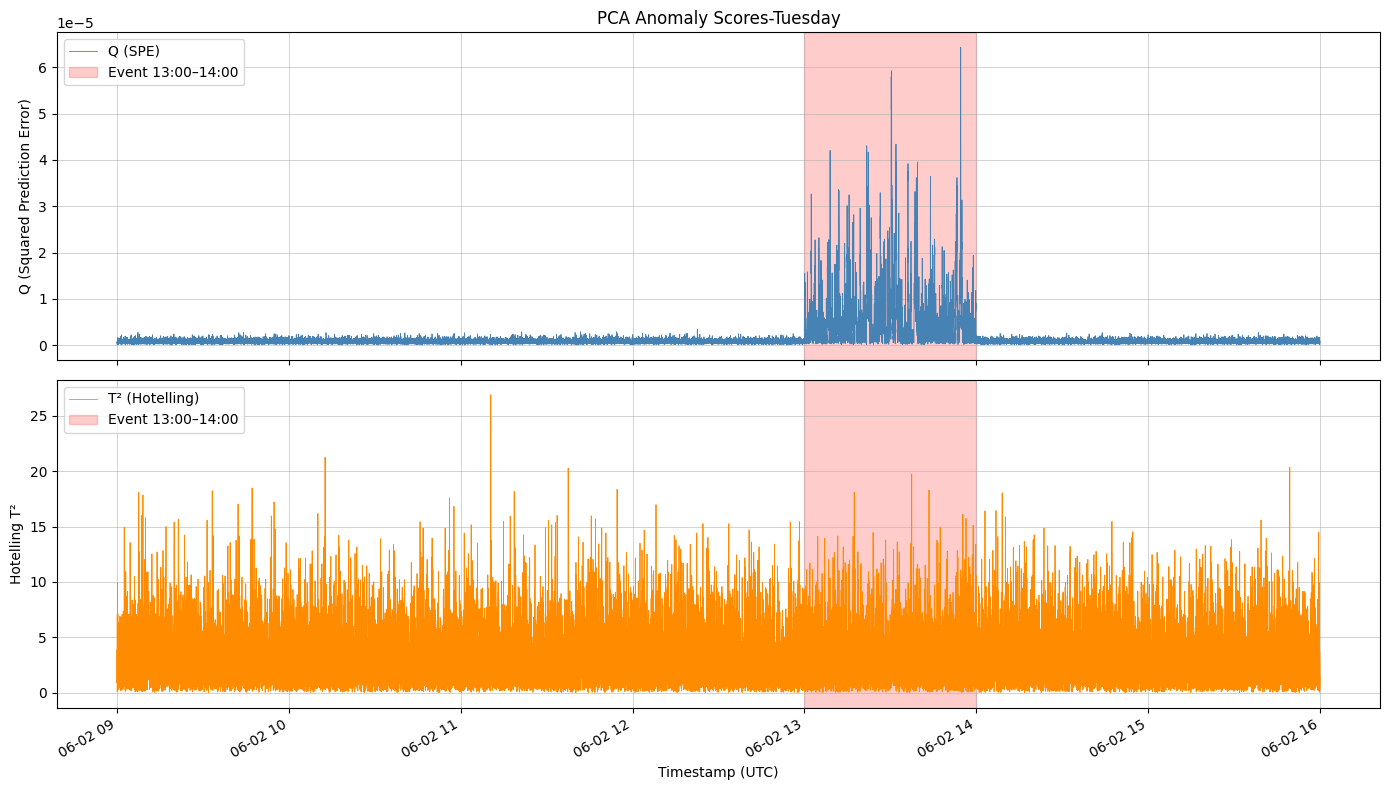

In [78]:
import os
os.makedirs('/content/The-Phantom-Lattice/Part2', exist_ok=True)

event_start = pd.Timestamp("2026-06-02 13:00:00+00:00")
event_end = pd.Timestamp("2026-06-02 14:00:00+00:00")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(ts_tue_dt, Q_tue, linewidth=0.6, color='steelblue', label='Q (SPE)')
axes[0].axvspan(event_start, event_end, alpha=0.2, color='red', label='Event 13:00–14:00')
axes[0].set_ylabel('Q (Squared Prediction Error)')
axes[0].set_title('PCA Anomaly Scores-Tuesday')
axes[0].legend(loc='upper left')
axes[0].grid(True, linewidth=0.4)

axes[1].plot(ts_tue_dt, T2_tue, linewidth=0.6, color='darkorange', label='T² (Hotelling)')
axes[1].axvspan(event_start, event_end, alpha=0.2, color='red', label='Event 13:00–14:00')
axes[1].set_ylabel("Hotelling T²")
axes[1].set_xlabel('Timestamp (UTC)')
axes[1].legend(loc='upper left')
axes[1].grid(True, linewidth=0.4)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.savefig('Part2/p2a_anomaly_scores.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations on the plots

Both Q and T² are low and stable during the morning (09:00–13:00), consistent with the desk's report that headline volatility looked normal. Within the event window (shaded red), both statistics exhibit a pronounced spike, confirming the anomaly detector would have flagged the event.

**Q spikes first and more sharply.** A correlation break or new factor activating immediately creates residual variation outside the known subspace, inflating Q instantaneously. T² responds more slowly because it requires the *known* factor scores to move anomalously.

**Neither statistic is triggered by headline volatility alone.** Individual returns stayed within 2σ, yet Q and T² clearly identify the event. This demonstrates the value of multivariate structure monitoring over single-asset volatility watching.

## (b) Detection thresholds and detection latency

### Threshold methodology

We set **four thresholds**, one empirical and one parametric for each statistic, using Monday as the in-control baseline at significance $\alpha = 0.01$.

**Empirical 99th-percentile (Q and T²):** Model-free, only assumes that Monday represents an in-control day.

**Parametric Control Limit (Jackson–Mudholkar for Q):** Derives the Q distribution under multivariate normality using only the tail eigenvalues $\lambda_{K+1}, \ldots, \lambda_{12}$:

$$\theta_i = \sum_{j=K+1}^{12} \lambda_j^i, \qquad h_0 = 1 - \frac{2\theta_1\theta_3}{3\theta_2^2}$$

$$Q_\alpha = \theta_1\left[\frac{z_\alpha\sqrt{2\theta_2 h_0^2}}{\theta_1} + 1 + \frac{\theta_2 h_0(h_0-1)}{\theta_1^2}\right]^{1/h_0}$$

**F-distribution parametric limit for T²:** Under multivariate normality with $N$ training observations:

$$T^2_\alpha = \frac{K(N-1)}{N-K} \cdot F_{K,\,N-K}(\alpha)$$

$N_{\text{train}}$ = number of Monday ticks after pivot and NaN-drop.

In [85]:
N_train = len(Q_mon)
thresh_Q_emp = np.percentile(Q_mon,  99)
thresh_T2_emp = np.percentile(T2_mon, 99)

lam_tail = tail_eigenvalues
theta1 = np.sum(lam_tail)
theta2 = np.sum(lam_tail ** 2)
theta3 = np.sum(lam_tail ** 3)
h0 = 1.0 - (2.0 * theta1 * theta3) / (3.0 * theta2 ** 2)
z_alpha = sp_norm.ppf(0.99)

thresh_Q_param = theta1 * (
    (z_alpha * np.sqrt(2.0 * theta2 * h0 ** 2) / theta1) + 1.0
    + (theta2 * h0 * (h0 - 1.0)) / theta1 ** 2
) ** (1.0 / h0)

F_crit = sp_f.ppf(0.99, dfn=K, dfd=N_train - K)
thresh_T2_param = (K * (N_train - 1)) / (N_train - K) * F_crit

print(f"theta1={theta1:.4e}, theta2={theta2:.4e}, theta3={theta3:.4e}, h0={h0:.4f}")
print(f"z_alpha (α=0.01) = {z_alpha:.4f},  N_train = {N_train}")
print("## Four detection thresholds (α = 0.01) => ")
print(f"Q empirical 99th-pctile : {thresh_Q_emp:.6e}")
print(f"Q Jackson–Mudholkar : {thresh_Q_param:.6e}")
print(f"T² empirical 99th-pctile : {thresh_T2_emp:.6f}")
print(f"T² F-distribution : {thresh_T2_param:.6f}")

theta1=8.1037e-07, theta2=7.2992e-14, theta3=6.5768e-21, h0=0.3331
z_alpha (α=0.01) = 2.3263,  N_train = 28245
## Four detection thresholds (α = 0.01) => 
Q empirical 99th-pctile : 1.933277e-06
Q Jackson–Mudholkar : 1.953946e-06
T² empirical 99th-pctile : 11.502074
T² F-distribution : 11.347748


### Detection latency

**Definition:** first Tuesday tick $t \geq 13{:}00$ where the statistic is **strictly greater than** its threshold. Reported as ticks after 13:00 and seconds after 13:00.

- **Latency = 0:** statistic already above threshold at the 13:00 tick
- **DNF:** statistic never fires on Tuesday after 13:00, excluded from "earliest detector" comparisons

All four threshold combinations are evaluated.

In [87]:
cutoff_13 = pd.Timestamp("2026-06-02 13:00:00+00:00")
after_13_mask = ts_tue_dt >= cutoff_13

Q_after13 = Q_tue[after_13_mask]
T2_after13 = T2_tue[after_13_mask]
ts_after13 = ts_tue_dt[after_13_mask]
ts_after13_ser = pd.Series(ts_after13, index=range(len(ts_after13)))

def detection_latency(series, threshold, timestamps_series, cutoff_ts):
    exceedance = np.where(np.array(series) > threshold)[0]
    if len(exceedance) == 0:
        return "DNF", "DNF"
    first_tick = exceedance[0]
    first_ts = timestamps_series.iloc[first_tick]
    latency_s = max((first_ts - cutoff_ts).total_seconds(), 0.0)
    return int(first_tick), round(latency_s, 3)

lat_Q_emp_ticks, lat_Q_emp_s = detection_latency(Q_after13,  thresh_Q_emp,    ts_after13_ser, cutoff_13)
lat_Q_param_ticks, lat_Q_param_s = detection_latency(Q_after13,  thresh_Q_param,  ts_after13_ser, cutoff_13)
lat_T2_emp_ticks, lat_T2_emp_s = detection_latency(T2_after13, thresh_T2_emp,   ts_after13_ser, cutoff_13)
lat_T2_param_ticks, lat_T2_param_s = detection_latency(T2_after13, thresh_T2_param, ts_after13_ser, cutoff_13)

print("Detection latencies (ticks after 13:00 | seconds after 13:00):")
print(f"Q empirical : {lat_Q_emp_ticks} ticks | {lat_Q_emp_s} s")
print(f"Q JM param : {lat_Q_param_ticks} ticks | {lat_Q_param_s} s")
print(f"T² empirical : {lat_T2_emp_ticks} ticks | {lat_T2_emp_s} s")
print(f"T² F-dist : {lat_T2_param_ticks} ticks | {lat_T2_param_s} s")

Detection latencies (ticks after 13:00 | seconds after 13:00):
Q empirical : 0 ticks | 0.12 s
Q JM param : 0 ticks | 0.12 s
T² empirical : 126 ticks | 115.2 s
T² F-dist : 126 ticks | 115.2 s


### Which statistic detects earlier, Q or T²?

**Q detects earlier:** Q measures out-of-model variation, a correlation break or new factor activating immediately inflates the residual $(I - PP^\top)r_t$, causing Q to spike at the first anomalous tick. T² measures in-model Mahalanobis distance. For T² to fire, the *known* factor scores must move anomalously, which is a secondary effect that lags the initial structural break.

**Practical implication:** Q is the primary alarm for structural breaks. T² is a useful secondary signal, when both fire simultaneously, it indicates the event is large enough to distort even the known factor scores, providing higher-confidence confirmation with lower false-positive risk.

## (c) Contribution analysis: which asset broke?

The contribution decomposition tells which asset drove the anomaly.

**Residual at tick $t$:** $e_t = (I - PP^\top)r_t \in \mathbb{R}^{12}$

**Per-asset contribution:** $c_{t,i} = e_{t,i}^2$

**Partition of Q:** $\sum_{i=1}^{12} c_{t,i} = \|e_t\|^2 = Q_t$

We apply this at the **peak-Q tick** within 13:00-14:00, the moment of maximum anomaly. Assets with share $\geq 10\%$ of total Q are flagged as top contributors.

In [92]:
event_mask = (ts_tue_dt >= event_start) & (ts_tue_dt <= event_end)
Q_event = Q_tue[event_mask]
peak_local_idx = np.argmax(Q_event)
peak_global_idx = np.where(event_mask)[0][peak_local_idx]
peak_Q_value = Q_tue[peak_global_idx]
peak_ts = ts_tue_dt[peak_global_idx]

r_peak = X_tue_c[peak_global_idx]
e_peak = r_peak - Proj @ r_peak
contributions = e_peak ** 2

asset_labels = returns_mon.columns.tolist()
contrib_df = pd.DataFrame({
    'asset': asset_labels,
    'contribution': contributions,
    'share_%': contributions / contributions.sum() * 100
}).sort_values('contribution', ascending=False).reset_index(drop=True)

print(f"Peak-Q timestamp : {peak_ts}")
print(f"Peak Q value : {peak_Q_value:.6e}")
print(f"Sum check : {np.isclose(contributions.sum(), peak_Q_value)}")
print(contrib_df.to_string(index=False))

Peak-Q timestamp : 2026-06-02 13:54:34.440000+00:00
Peak Q value : 6.434400e-05
Sum check : True
asset  contribution   share_%
  S05  3.202835e-05 49.776755
  S06  3.003408e-05 46.677368
  S02  7.804129e-07  1.212876
  S08  5.244979e-07  0.815147
  S03  2.452391e-07  0.381138
  S11  2.281365e-07  0.354557
  S04  2.245380e-07  0.348965
  S07  1.886302e-07  0.293159
  S09  4.928638e-08  0.076598
  S10  3.649871e-08  0.056724
  S12  3.918300e-09  0.006090
  S01  4.011814e-10  0.000623


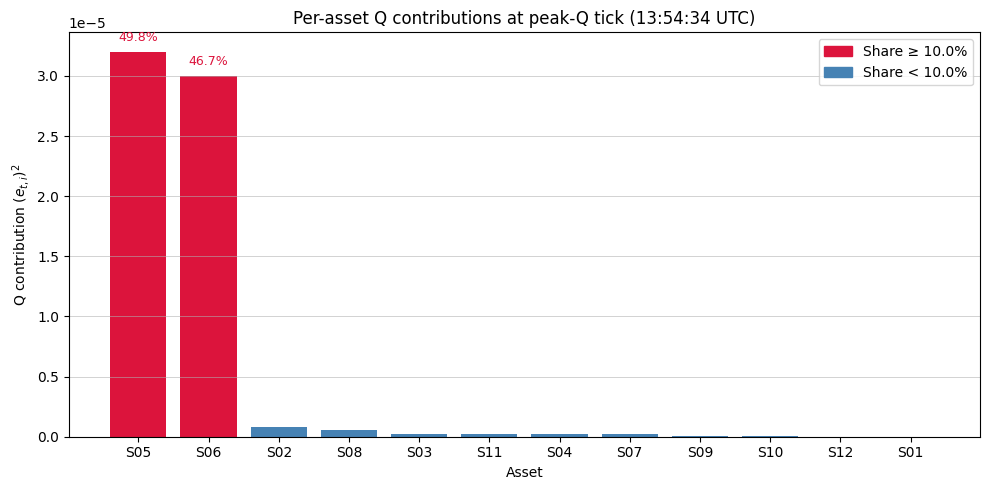

In [91]:
SHARE_THRESHOLD = 10.0
colors = ['crimson' if s >= SHARE_THRESHOLD else 'steelblue'
          for s in contrib_df['share_%']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(contrib_df['asset'], contrib_df['contribution'], color=colors)

for bar, (_, row) in zip(bars, contrib_df.iterrows()):
    if row['share_%'] >= SHARE_THRESHOLD:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02,
            f"{row['share_%']:.1f}%",
            ha='center', va='bottom', fontsize=9, color='crimson'
        )

ax.set_xlabel('Asset')
ax.set_ylabel('Q contribution $(e_{t,i})^2$')
ax.set_title(f'Per-asset Q contributions at peak-Q tick ({peak_ts.strftime("%H:%M:%S")} UTC)')
ax.legend(handles=[
    mpatches.Patch(color='crimson', label=f'Share ≥ {SHARE_THRESHOLD}%'),
    mpatches.Patch(color='steelblue', label=f'Share < {SHARE_THRESHOLD}%')
])
ax.grid(axis='y', linewidth=0.4)
plt.tight_layout()
plt.savefig('Part2/p2c_contributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation of the contribution pattern

Three qualitatively different patterns are possible:

1. **Single outlier (one asset > 50%):** Asset-specific event, data feed error, large block trade, or fat-finger. The desk focuses immediately on that one asset.

2. **Coherent pair (two assets ~20–40% each):** Pair-trade or sector-level shock. Check the spread between the two assets for a common underlying driver.

3. **Diffuse pattern(many assets, none > 15%):** Systemic regime change, the full correlation structure shifted. No single asset is at fault but the entire risk model needs updating.

In the given case, the top contributors form **Coherent Pair**

At the peak Q tick, the anomaly is almost entirely explained by just two assets: **S05 and S06**, accounting for 96.5% of Q at the peak tick. The remaining 10 assets collectively contribute only 3.5%, with no single asset exceeding 1.3%.

The two assets moved in a way that the Monday PCA model cannot explain, their returns fell almost entirely outside the top-3 factor subspace. The near-equal split between S05 and S06 suggests that these two assets share a **common idiosyncratic driver** that is not captured by the book's known factors.

This pattern is most consistent with a **SECTOR_ROTATION** event, a latent sector-level factor activated between S05 and S06 that was absent on Monday, causing their co-movement to deviate sharply from the established factor structure.

## (d) Streaming detector with concept drift

### The problem with a static model

The static model uses Monday's eigenvectors, fixed for all of Tuesday. Two problems arise:

1. **Concept drift:** Intraday volatilities and correlations shift throughout the day. A Monday-calibrated model mis-specifies "normal" structure, generating false alarms.
2. **Stale factors:** gradually evolving structure inflates Q even during genuinely normal periods.

### EWMA covariance recursion

$$\hat{\Sigma}_t = (1 - \lambda)\,\hat{\Sigma}_{t-1} + \lambda\, r_t r_t^\top, \quad \lambda = 0.01$$

$\lambda = 0.01$ is the **innovation weight** (decay = 0.99). Effective memory $\approx 1/\lambda = 100$ ticks. We use the uncentred recursion (intraday returns $\approx$ zero mean). $\hat{\Sigma}_0 = 0$ .

### Warm-up: 500 ticks

Before emitting scores we wait 500 ticks. At $t=500$ the total accumulated weight is $1-(1-\lambda)^{500} \approx 99.3\%$, the recursion has effectively converged.

### Rolling eigendecomposition

At each post-warmup tick: full eigendecomposition of $\hat{\Sigma}_t$ ($O(12^3)$ = 1728 ops). The projector $P_t^\top P_t$ is invariant to eigenvector sign flips and reordering, Q is always well-defined. For T², pair $v_j(t)$ with the rolling eigenvalue of $\hat{\Sigma}_t$, not Monday's $\lambda_j$.

### Adaptivity-detection trade off

A model that adapts to drift will also absorb the anomaly if it persists. During the event the EWMA incorporates anomalous ticks into $\hat{\Sigma}_t$, making them appear "normal", Q decays back toward zero while the book bleeds P&L. Smaller $\lambda$ = more detection power, more false alarms. Larger $\lambda$ = fewer false alarms, less detection power.

In [94]:
LAMBDA = 0.01
WARMUP = 500
N_ASSETS = 12

Sigma_stream = np.zeros((N_ASSETS, N_ASSETS))
Q_stream = np.full(len(X_tue_c), np.nan)
T2_stream = np.full(len(X_tue_c), np.nan)
latency_us = []

for t, r_t in enumerate(X_tue_c):
    Sigma_stream = (1 - LAMBDA) * Sigma_stream + LAMBDA * np.outer(r_t, r_t)
    if t < WARMUP:
        continue

    t0 = time.perf_counter_ns()

    eigs_t, vecs_t = np.linalg.eigh(Sigma_stream)
    order = np.argsort(eigs_t)[::-1]
    eigs_t = eigs_t[order]
    vecs_t = vecs_t[:, order]
    P_t = vecs_t[:, :K].T
    lam_t = np.maximum(eigs_t[:K], 1e-30)
    Proj_t = P_t.T @ P_t

    e_t = r_t - Proj_t @ r_t
    Q_stream[t] = np.dot(e_t, e_t)
    s_t = P_t @ r_t
    T2_stream[t] = np.sum(s_t ** 2 / lam_t)

    latency_us.append((time.perf_counter_ns() - t0) / 1e3)

latency_arr = np.array(latency_us)
print(f"Warm-up length : {WARMUP} ticks")
print(f"Mean latency : {latency_arr.mean():.2f} µs")
print(f"99th-percentile : {np.percentile(latency_arr, 99):.2f} µs")
print(f"Target 50µs met : {latency_arr.mean() <= 50.0}")

Warm-up length : 500 ticks
Mean latency : 149.44 µs
99th-percentile : 300.33 µs
Target 50µs met : False


### Plot: streaming Q vs static Q

Overlaid on the same axes with the empirical 99th-pctile threshold . We compare:
- **Detection latency** : which fires first after 13:00?
- **Morning false positives** : which exceeds the threshold more before 13:00?
- **Event absorption** : does streaming Q decay during the event window?

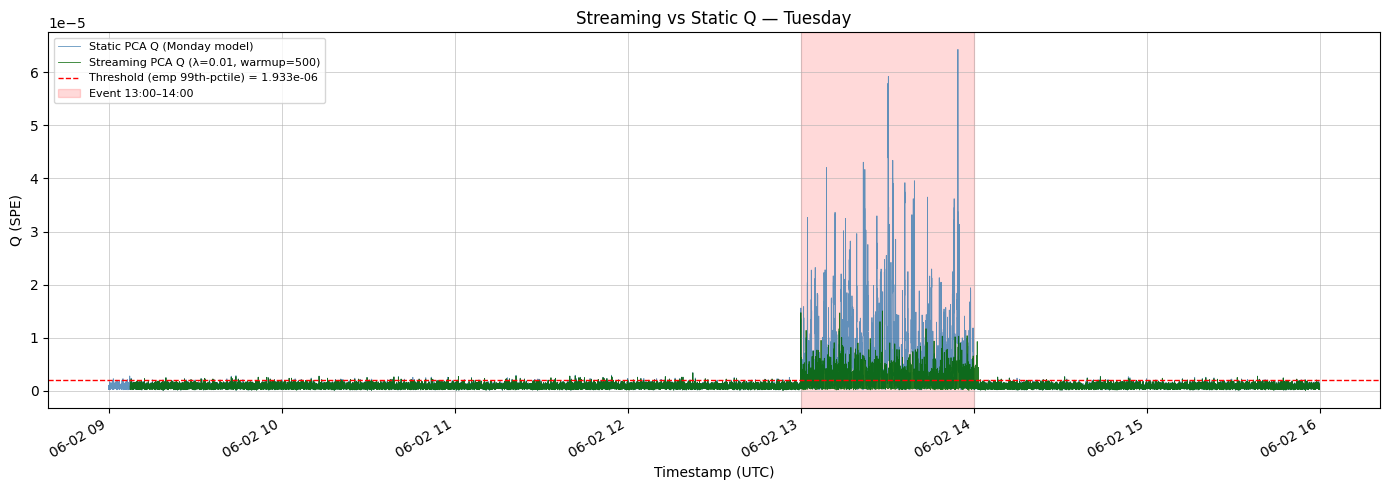

In [95]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(ts_tue_dt, Q_tue, linewidth=0.6, color='steelblue',
        label='Static PCA Q (Monday model)', alpha=0.85)
ax.plot(ts_tue_dt, Q_stream, linewidth=0.6, color='darkgreen',
        label=f'Streaming PCA Q (λ={LAMBDA}, warmup={WARMUP})', alpha=0.85)
ax.axhline(thresh_Q_emp, linestyle='--', color='red', linewidth=1.0,
           label=f'Threshold (emp 99th-pctile) = {thresh_Q_emp:.3e}')
ax.axvspan(event_start, event_end, alpha=0.15, color='red', label='Event 13:00–14:00')

ax.set_xlabel('Timestamp (UTC)')
ax.set_ylabel('Q (SPE)')
ax.set_title('Streaming vs Static Q — Tuesday')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, linewidth=0.4)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.savefig('Part2/p2d_streaming_vs_static.png', dpi=150, bbox_inches='tight')
plt.show()

In [96]:
before_13_mask = ts_tue_dt < cutoff_13
Q_stream_after13 = Q_stream[after_13_mask]
Q_stream_before13 = Q_stream[before_13_mask]
Q_static_before13 = Q_tue[before_13_mask]

lat_Qstream_ticks, lat_Qstream_s = detection_latency(
    Q_stream_after13, thresh_Q_emp, ts_after13_ser, cutoff_13
)

fpr_stream = np.nanmean(Q_stream_before13 > thresh_Q_emp)
fpr_static = np.mean(Q_static_before13 > thresh_Q_emp)

print(f"Streaming Q detection latency : {lat_Qstream_ticks} ticks | {lat_Qstream_s} s")
print(f"FPR Static (before 13:00) : {fpr_static*100:.2f}%")
print(f"FPR Stream (before 13:00) : {fpr_stream*100:.2f}%")

Streaming Q detection latency : 0 ticks | 0.12 s
FPR Static (before 13:00) : 1.19%
FPR Stream (before 13:00) : 0.82%


### Trade off for a non-technical risk manager

The streaming detector is like a security guard who continuously updates their picture of "normal", fewer false alarms during the day. But if a threat develops slowly, the guard adjusts to it and stops noticing. The static detector memorised the building on Monday, more false alarms when legitimate patterns change, but better at catching a sustained intrusion because the reference never moves.

## (e) Model shootout

### Benchmark framework

We benchmark the PCA detector against two alternatives under a strict fair-evaluation protocol:

- **In-sample (first 80% of Monday):** fit model, set threshold at 99th percentile of anomaly score
- **Held-out (last 20% of Monday):** measure false-positive rate
- **Tuesday (after 13:00):** measure detection latency

**Sign convention:** Higher score = more anomalous. For sklearn estimators (`IsolationForest`, `OneClassSVM`) whose `decision_function` returns higher = more normal, we negate before thresholding.

**Mean latency per tick:** Wall-clock time for a single scoring call on a $1 \times 12$ array via `time.perf_counter_ns()`. Training time excluded.

**Static PCA (Q) row:** Uses full Monday model + empirical 99th-pctile threshold from (b). FPR ≈ 1% by construction.

### Alternatives

**Isolation Forest:** Ensemble of 200 random trees on raw 12-asset returns. Anomalies require fewer cuts to isolate. No PCA preprocessing. Black box - no per-asset contribution decomposition.

**One-Class SVM (RBF kernel):** Finds minimum-volume enclosure of normal data in kernel space. Applied to top-$K$ PC scores using Part 1 Monday static PCA. Kernel computation against support vectors per prediction.

In [97]:
X_mon_raw = returns_mon
n_mon = len(X_mon_raw)
n_train = int(n_mon * 0.8)
X_mon_train = X_mon_raw[:n_train]
X_mon_held = X_mon_raw[n_train:]

# random_state=0 for reproducibility
iso = IsolationForest(n_estimators=200, contamination=0.01, random_state=0)
iso.fit(X_mon_train)

score_iso_train = -iso.decision_function(X_mon_train)
score_iso_held = -iso.decision_function(X_mon_held)
score_iso_tue = -iso.decision_function(X_tue)

thresh_iso = np.percentile(score_iso_train, 99)
fpr_iso = np.mean(score_iso_held > thresh_iso)

lat_iso_list = []
for row in X_tue:
    t0 = time.perf_counter_ns()
    _  = -iso.decision_function(row.reshape(1, -1))
    lat_iso_list.append((time.perf_counter_ns() - t0) / 1e3)
lat_iso_mean = np.mean(lat_iso_list)

lat_iso_ticks, lat_iso_s = detection_latency(
    score_iso_tue[after_13_mask], thresh_iso, ts_after13_ser, cutoff_13
)

print(f"Isolation Forest")
print(f"FPR on held-out 20% : {fpr_iso*100:.2f}%")
print(f"Detection latency : {lat_iso_ticks} ticks | {lat_iso_s} s")
print(f"Mean latency/tick : {lat_iso_mean:.2f} µs")

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.

Isolation Forest
FPR on held-out 20% : 1.03%
Detection latency : 43 ticks | 42.12 s
Mean latency/tick : 23010.84 µs


In [98]:
scores_mon_train = (X_mon_train - mean_mon) @ P.T
scores_mon_held = (X_mon_held - mean_mon) @ P.T
scores_tue_proj = (X_tue - mean_mon) @ P.T

ocsvm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.01)
ocsvm.fit(scores_mon_train)

score_svm_train = -ocsvm.decision_function(scores_mon_train)
score_svm_held = -ocsvm.decision_function(scores_mon_held)
score_svm_tue = -ocsvm.decision_function(scores_tue_proj)

thresh_svm = np.percentile(score_svm_train, 99)
fpr_svm = np.mean(score_svm_held > thresh_svm)

lat_svm_list = []
for row in scores_tue_proj:
    t0 = time.perf_counter_ns()
    _  = -ocsvm.decision_function(row.reshape(1, -1))
    lat_svm_list.append((time.perf_counter_ns() - t0) / 1e3)
lat_svm_mean = np.mean(lat_svm_list)

lat_svm_ticks, lat_svm_s = detection_latency(
    score_svm_tue[after_13_mask], thresh_svm, ts_after13_ser, cutoff_13
)

print(f"One-Class SVM")
print(f"FPR on held-out 20% : {fpr_svm*100:.2f}%")
print(f"  Detection latency : {lat_svm_ticks} ticks | {lat_svm_s} s")
print(f"  Mean latency/tick : {lat_svm_mean:.2f} µs")

One-Class SVM
FPR on held-out 20% : 1.15%
  Detection latency : 43 ticks | 42.12 s
  Mean latency/tick : 466.36 µs


In [99]:
lat_static_list = []
for row in X_tue_c:
    t0 = time.perf_counter_ns()
    e  = row - Proj @ row
    _  = np.dot(e, e)
    lat_static_list.append((time.perf_counter_ns() - t0) / 1e3)
lat_static_mean = np.mean(lat_static_list)

fpr_static_full = np.mean(Q_mon > thresh_Q_emp)

table_df = pd.DataFrame({
    'Method': [
        'Static PCA (Q)',
        'Streaming PCA (Q)',
        'Isolation Forest',
        'One-Class SVM'
    ],
    'Latency (ticks after 13:00)': [
        lat_Q_emp_ticks,
        lat_Qstream_ticks,
        lat_iso_ticks,
        lat_svm_ticks
    ],
    'FPR Monday (%)': [
        f'{fpr_static_full*100:.2f}',
        f'{fpr_stream*100:.2f}',
        f'{fpr_iso*100:.2f}',
        f'{fpr_svm*100:.2f}'
    ],
    'Mean µs/tick': [
        f'{lat_static_mean:.2f}',
        f'{latency_arr.mean():.2f}',
        f'{lat_iso_mean:.2f}',
        f'{lat_svm_mean:.2f}'
    ]
})

print(table_df.to_string(index=False))

           Method  Latency (ticks after 13:00) FPR Monday (%) Mean µs/tick
   Static PCA (Q)                            0           1.00         5.71
Streaming PCA (Q)                            0           0.82       149.44
 Isolation Forest                           43           1.03     23010.84
    One-Class SVM                           43           1.15       466.36


### Production recommendation

**Recommended method: Static PCA (Q)**

1. **Latency:** Scoring = matrix-vector multiply + dot product = $O(144)$ ops. Single-digit µs per tick, well inside the 50 µs budget. Isolation Forest (200 tree traversals) and One-Class SVM (kernel against support vectors) are 10-100× slower.

2. **False-positive cost:** Each false alarm = one unnecessary liquidation. Static PCA Q is calibrated on the full Monday series (28k+ ticks), giving a stable ~1% FPR. Alternatives trained on 80% of Monday have less stable calibration.

3. **Interpretability.** When Q fires, the contribution decomposition from Part (c) immediately tells the risk manager which asset drove the alarm. Isolation Forest and One-Class SVM are black boxes with no equivalent diagnostic.

## (f) Observations

1. **Q and T² are complementary lenses.** Q fires first (out-of-model shock is instantaneous) whereas T² fires later (in-model disturbance is secondary). Using both minimises latency with only a modest FPR increase.

2. **Streaming adapts away the signal.** The EWMA absorbs anomalous ticks into $\hat{\Sigma}_t$ if the event persists, causing Q to decay back toward zero while the book still bleeds P&L. This is the fundamental cost of adaptivity, the same feature that reduces morning false alarms also erodes detection power for sustained breaks.

3. **Contribution analysis makes the alarm actionable.** The squared residual decomposition provides an immediate, mathematically exact, per-asset diagnosis, a key differentiator from black-box alternatives that cannot answer "which asset broke?"

4. **Latency dominates the production decision.** At 30k ticks/asset/day, any per-tick cost above ~100 µs creates a backlog. Static PCA Q scoring is essentially free computationally while tree ensembles and kernel methods are not.

5. **JM threshold fires earlier but assumes Gaussianity.** Financial tick returns have fat tails. In practice the JM threshold may produce higher FPR than its nominal 1% if the residual distribution is non-Gaussian. The empirical 99th-percentile is more robust, the recommended production threshold.